In [1]:
%load_ext autoreload
%autoreload 2

# import sys, os
# sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'bilateral-m1-pcca', 'tools'))
# # Simpler if you run the notebook from the repo root:
# sys.path.insert(0, 'tools')


In [2]:
import scipy.io
import numpy as np
from tools.load_session import inspect_session, load_session
from tools.trial_epoching import get_session_trial_start_frames, get_session_touch_onset_frames, get_trial_outcome, compute_derived    
from tools.plotting_fncs import plot_trial_variable, plot_session_metrics
from tools.input_data_generation import get_neuron_mask, build_spike_count_matrices, prepare_session_for_pcca
from tools.run_save_model import fit_session_pcca, extract_session_metrics, save_session_results#, run_or_load_session
from tools.load_session import TIME_STEP
import matplotlib.pyplot as plt
%matplotlib widget


In [11]:
# inspect_session('data/P2.mat')

In [14]:
session_id='P2'
session_data = load_session(f'data/{session_id}.mat')
derived = compute_derived(session_data)

## U7, U8 problem
## U1 only has 17 neurons in LH




In [4]:
### Stimulus and outcome information

print(f' All Unique stimuli: {set(derived["trial_stimulus"])}')
print(f' Rewarded stimuli: {set([derived["trial_stimulus"][i] for i, o in enumerate(derived["trial_outcome"]) if o in ["hit", "miss"]])}')
print(f' Unrewarded stimuli: {set([derived["trial_stimulus"][i] for i, o in enumerate(derived["trial_outcome"]) if o in ["false_alarm", "correct_rej"]])}')
print()
print(f' Trial stimulus counts:')
for stim in set(derived["trial_stimulus"]):
    print(f'  {stim}: {derived["trial_stimulus"].count(stim)}')
print()
print('Trial outcome counts:')
print(f' Total hit trials: {sum([1 for o in derived["trial_outcome"] if o == "hit"])}')
print(f' Total miss trials: {sum([1 for o in derived["trial_outcome"] if o == "miss"])}')
print(f' Total false alarm trials: {sum([1 for o in derived["trial_outcome"] if o == "false_alarm"])}')
print(f' Total correct rejection trials: {sum([1 for o in derived["trial_outcome"] if o == "correct_rej"])}')

 All Unique stimuli: {'leftC', 'none', 'rightC+leftC', 'rightC', 'rightC+leftD', 'rightD+leftD', 'leftD', 'rightD+leftC', 'rightD'}
 Rewarded stimuli: {'rightD+leftD', 'rightC+leftC'}
 Unrewarded stimuli: {'leftC', 'none', 'rightC', 'rightC+leftD', 'leftD', 'rightD+leftC', 'rightD'}

 Trial stimulus counts:
  leftC: 43
  none: 21
  rightC+leftC: 122
  rightC: 44
  rightC+leftD: 124
  rightD+leftD: 122
  leftD: 33
  rightD+leftC: 96
  rightD: 29

Trial outcome counts:
 Total hit trials: 196
 Total miss trials: 48
 Total false alarm trials: 8
 Total correct rejection trials: 382


In [5]:
### Neuronal data information

print(f'LH neurons: {session_data["n_lh"]}, RH neurons: {session_data["n_rh"]}, Total neurons: {session_data["n_lh"] + session_data["n_rh"]}')

rs = np.sum(session_data['fsrs'] == 1)
fs = np.sum(session_data['fsrs'] == -1)
un = np.sum(session_data['fsrs'] == 0)

print(f"RS: {rs}, FS: {fs}, UN: {un}")

for hemi, mask in [('LH', session_data['loc_lh_mask']), ('RH', session_data['loc_rh_mask'])]:
    fsrs = session_data['fsrs'][mask]
    print(f"{hemi}  RS: {(fsrs==1).sum()}  FS: {(fsrs==-1).sum()}  UN: {(fsrs==0).sum()}")


LH neurons: 110, RH neurons: 129, Total neurons: 239
RS: 229, FS: 3, UN: 7
LH  RS: 109  FS: 0  UN: 1
RH  RS: 120  FS: 3  UN: 6


In [15]:
# Print name and shape of all variables in the derivesd dictionary
print("Derived variables:")
for key, value in derived.items():
    print(f"{key}: {np.shape(value)}")

Derived variables:
trial_start_frames: (634,)
touch_onset_frames: (634,)
trial_outcome: (634,)
trial_stimulus: (634,)
trial_first_lick_frames: (634,)


Hit trials : 196
Touch latency — mean: 0.644 s  median: 0.642 s
Lick latency  — mean: 1.729 s  median: 1.793 s


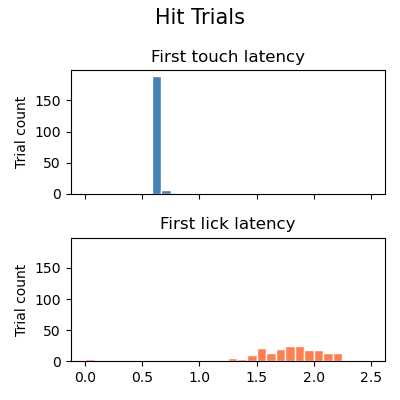

In [33]:

# ── Reference point: swap between trial start and stimulus onset ──────────
reference_frames = derived['trial_start_frames']   # trial start
# reference_frames = derived['trial_start_frames'] + 0.5        # stimulus onset

# ── Hit trials only ───────────────────────────────────────────────────────
hit_mask = np.array([o == 'hit' for o in derived['trial_outcome']])
# ── Latencies (seconds) ───────────────────────────────────────────────────
touch_latency_s = (derived['touch_onset_frames'][hit_mask] - reference_frames[hit_mask]) * TIME_STEP
lick_latency_s  = (derived['trial_first_lick_frames'][hit_mask]  - reference_frames[hit_mask]) * TIME_STEP

print(f"Hit trials : {hit_mask.sum()}")
print(f"Touch latency — mean: {np.nanmean(touch_latency_s):.3f} s  median: {np.nanmedian(touch_latency_s):.3f} s")
print(f"Lick latency  — mean: {np.nanmean(lick_latency_s):.3f} s  median: {np.nanmedian(lick_latency_s):.3f} s")

bins = np.linspace(0, 2.5, 31)  # 30 bins between 0 and 2.5

fig, axes = plt.subplots(2, 1, figsize=(4, 4), sharey=True, sharex=True)

axes[0].hist(touch_latency_s[~np.isnan(touch_latency_s)], bins=bins, color='steelblue', edgecolor='white')
axes[0].set_ylabel('Trial count')
axes[0].set_title('First touch latency')

axes[1].hist(lick_latency_s[~np.isnan(lick_latency_s)], bins=bins, color='coral', edgecolor='white')
axes[1].set_ylabel('Trial count')
axes[1].set_title('First lick latency')

plt.suptitle('Hit Trials', fontsize=15)
plt.tight_layout()
plt.show()



In [ ]:
# # Inspect a single trial

# trial_idx=99

# valid_vars = ['piston_frames', 'touch_frames', 'licks',
#             #   'whisker_angle', 'curvature','phase', 'run_speed', 
#               'hits', 'misses', 'false_alarms','correct_rejs', 
#               ]
# for var_name in valid_vars:
#     if var_name in ['hits', 'misses', 'false_alarms', 'correct_rejs', 'licks']:
#         plot_trial_variable(session_data, derived['trial_start_frames'], var_name=var_name, trial_idx=trial_idx, ylim=(-0.1, 1.1))
#     else:
#         plot_trial_variable(session_data, derived['trial_start_frames'], var_name=var_name, trial_idx=trial_idx)


In [ ]:
# Include only trials with valid stimuli (i.e., not None)
stim_valid_mask = np.array([s is not 'none' for s in derived['trial_stimulus']])

# Include only trials with hit, miss, or correct rejection outcomes (exclude false alarms) (hit trials with lick latency > 1.0 s are also excluded)
hit_mask = np.array([o == 'hit' for o in derived['trial_outcome']])
miss_mask = np.array([o == 'miss' for o in derived['trial_outcome']])
correct_rej_mask = np.array([o == 'correct_rej' for o in derived['trial_outcome']])
false_alarm_mask = np.array([o == 'false_alarm' for o in derived['trial_outcome']])

hit_fast_lick_mask = hit_mask.copy()
hit_fast_lick_mask[hit_mask] = lick_latency_s > 1.0

combined_mask = (hit_fast_lick_mask | miss_mask | correct_rej_mask) & stim_valid_mask
filtered_trial_indices = np.where(combined_mask)[0]

print(f"Filtered trials: {len(filtered_trial_indices)}")

lh_neuron_mask = get_neuron_mask(session_data, hemisphere='LH', fsrs=[1, -1], min_rate_hz=5.0)
rh_neuron_mask = get_neuron_mask(session_data, hemisphere='RH', fsrs=[1, -1], min_rate_hz=5.0)

In [ ]:
windows = [(0.0, 1.0), (0.0, 0.5), (0.5, 1.0)]

for window in windows:
    win_label = f'{window[0]:.1f}-{window[1]:.1f}'
    sid = f'{session_id}_w{win_label}'
    print(f'\n=== Window {win_label} s ===')

    bundle = prepare_session_for_pcca(
        session_data   = session_data,
        derived        = derived,
        trial_indices  = filtered_trial_indices,
        window         = window,
        lh_neuron_mask = lh_neuron_mask,
        rh_neuron_mask = rh_neuron_mask,
    )

    model, cv_results = fit_session_pcca(bundle, d_max=6, n_folds=10, rand_seed=42)
    metrics, summary  = extract_session_metrics(model, session_id=sid)
    save_session_results(sid, model, cv_results, metrics, summary)
    fig = plot_session_metrics(metrics, summary, session_id=sid)

In [ ]:
# Superseded by the windows loop above.
# model, cv_results = fit_session_pcca(bundle, d_max=6, n_folds=10, rand_seed=42)
# metrics, summary = extract_session_metrics(model, session_id=session_id)
# save_session_results(session_id, model, cv_results, metrics, summary)

In [128]:
# print("d =", model.params['d'])
# print("d1 =", model.params['d1'], "  L_1 shape:", model.params['L_1'].shape)
# print("d2 =", model.params['d2'], "  L_2 shape:", model.params['L_2'].shape)


In [ ]:
# from tools.run_save_model import load_session_results
# model_old, cv_results_old, metrics_old, summary_old = load_session_results(session_id)

Loaded ← results/P2.joblib  (d=6, d1=6, d2=3)


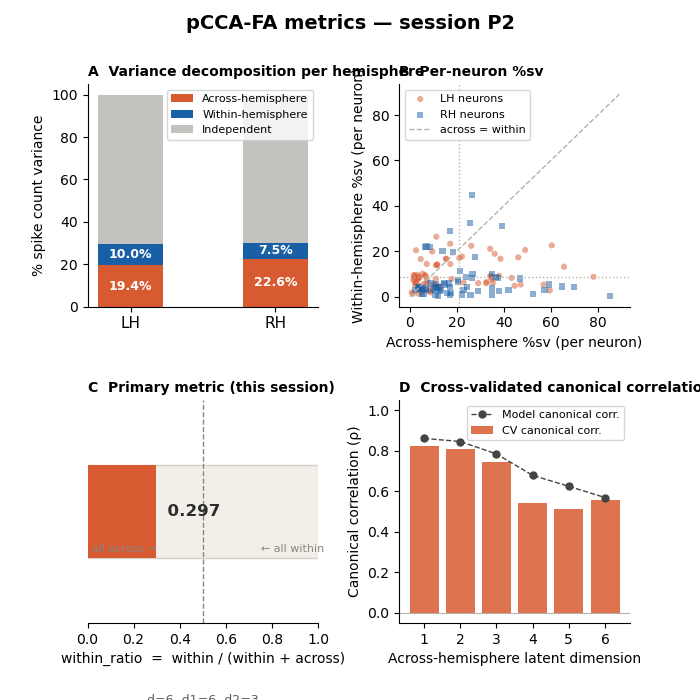

In [ ]:
# fig = plot_session_metrics(metrics_old, summary_old, session_id=session_id)

In [ ]:
# Superseded by the windows loop above.
# fig = plot_session_metrics(metrics, summary, session_id=session_id)

In [130]:
# # Call this on your preprocessed matrices
# z, LL = model.estep(bundle['lh'], bundle['rh'])

# z['z_mu']    # (T, d)   ← across-hemisphere latent variables, one value per trial
# z['zx1_mu']  # (T, d1)  ← within-LH latent variables per trial
# z['zx2_mu']  # (T, d2)  ← within-RH latent variables per trial
# # z_cov, zx1_cov, zx2_cov also available — posterior uncertainty per dimension

In [131]:
# metrics['psv'].keys()
# dict_keys(['psv_W_1', 'psv_W_2', 'psv_L_1', 'psv_L_2', 'avg_psv_W_1', 'avg_psv_W_2', 'avg_psv_L_1', 'avg_psv_L_2', 'ind_var_x1', 'ind_var_x2', 'avg_psv_W_total', 'avg_psv_L_total'])

In [132]:
summary

{'session_id': 'P3',
 'avg_psv_W': 25.397028376437735,
 'avg_psv_L': 3.4440049995142363,
 'within_ratio': 0.1194133703401173,
 'avg_psv_W_lh': 27.636876842914926,
 'avg_psv_L_lh': 3.1061839883069355,
 'avg_psv_W_rh': 23.26383936074517,
 'avg_psv_L_rh': 3.7657392959021427,
 'within_ratio_lh': 0.10103691383755696,
 'within_ratio_rh': 0.13931920078140192,
 'd': 6,
 'd1': 1,
 'd2': 1}

In [133]:
# # ── putting it together for one session ───────────────────────────────────────

# def run_session(bundle, session_id=None, d_max=6, n_folds=10, rand_seed=42):
#     """
#     Full Steps 4+5 for one session. Call this per animal.

#     Returns model, cv_results, metrics, summary.
#     """
#     model, cv_results = fit_session_pcca(
#         bundle, d_max=d_max, n_folds=n_folds, rand_seed=rand_seed
#     )
#     metrics, summary = extract_session_metrics(model, session_id=session_id)

#     print(f"\n── Session {session_id} ──────────────────────")
#     print(f"  across %sv : {summary['avg_psv_W']:.2f}%")
#     print(f"  within %sv : {summary['avg_psv_L']:.2f}%")
#     print(f"  within_ratio (primary): {summary['within_ratio']:.4f}")

#     return model, cv_results, metrics, summary

# from scipy.stats import mannwhitneyu
# import pandas as pd

# # collect per-session summaries into a dataframe
# # run_session() once per animal, label each with training group
# records = []
# for session_id, bundle, group in session_list:   # group = 'unilateral' or 'bilateral'
#     _, _, _, summary = run_session(bundle, session_id=session_id)
#     summary['group'] = group
#     records.append(summary)

# df = pd.DataFrame(records)

# # group-level comparison on the primary metric
# uni = df.loc[df['group'] == 'unilateral', 'within_ratio']
# bil = df.loc[df['group'] == 'bilateral',  'within_ratio']

# stat, p = mannwhitneyu(uni, bil, alternative='greater')  # H1: unilateral > bilateral

# print(f"\nMann-Whitney U:  U={stat:.1f},  p={p:.4f}")
# print(f"Unilateral within_ratio:  mean={uni.mean():.4f}, n={len(uni)}")
# print(f"Bilateral  within_ratio:  mean={bil.mean():.4f}, n={len(bil)}")